# VitalScan — Group 1 Demo Notebook

**Course:** AIT 500 · Westcliff University  
**Group:** 1 of 4 — rPPG signal extraction  
**Repo:** [gbiz21/vitalscan](https://github.com/gbiz21/vitalscan)  
**Live demo:** https://vitalscan.bkre8tive.com

This notebook is **Deliverable 1** from the project brief:

> _A Python script or Jupyter notebook that takes a 30-second video file and outputs a valid biomarker JSON object matching the shared contract._

It walks the rPPG signal chain end-to-end on a single example video and prints the final JSON that the FastAPI `/scan` endpoint returns in production:

```
Video → Face detection → ROI → RGB time-series → POS → Bandpass → FFT → biomarkers
```

See `docs/figures/figure1-signal-chain.svg` for the architectural view.

## Setup

Import the rPPG package from the repo and configure the demo video path. Run this notebook from the repo root so `backend/` is on the import path.

In [9]:
import json
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'backend').exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from backend.rppg.face_detection import FaceROIExtractor
from backend.rppg.pos_algorithm import (
    extract_heart_rate, butter_bandpass, estimate_heart_rate_fft, pos_algorithm,
)
from backend.rppg.chrom_baseline import extract_heart_rate_chrom
from backend.rppg.hrv import compute_hrv_metrics, detect_pulse_peaks, compute_ibi
from backend.rppg.pipeline import run_pipeline

# Demo input — a UBFC-rPPG Dataset 2 subject (real human, ground truth available)
VIDEO_PATH = REPO_ROOT / 'data/ubfc_full/UBFC_DATASET/DATASET_2/subject1/vid.avi'
print(f'Video: {VIDEO_PATH}')
print(f'Exists: {VIDEO_PATH.exists()}')

Video: /Users/gbeazer/05_Projects/vitalscan/data/ubfc_full/UBFC_DATASET/DATASET_2/subject1/vid.avi
Exists: True


## Stage 1 — Face Detection and ROI Extraction (Task 1)

Run MediaPipe FaceMesh on every frame. The model returns 468 facial landmarks per frame; we extract three regions — forehead, left cheek, right cheek — which have the highest capillary density and produce the cleanest rPPG signal. For each frame we average the pixel values inside the ROI polygons to get a single `(R, G, B)` per frame.

I0000 00:00:1778759331.561981 10804444 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M3 Max
W0000 00:00:1778759331.562998 10805830 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778759331.565367 10805830 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Frames with detected face: 1547
Video fps: 29.3
Duration: 52.9 seconds
RGB time-series shape: (1547, 3)  # (T, 3)


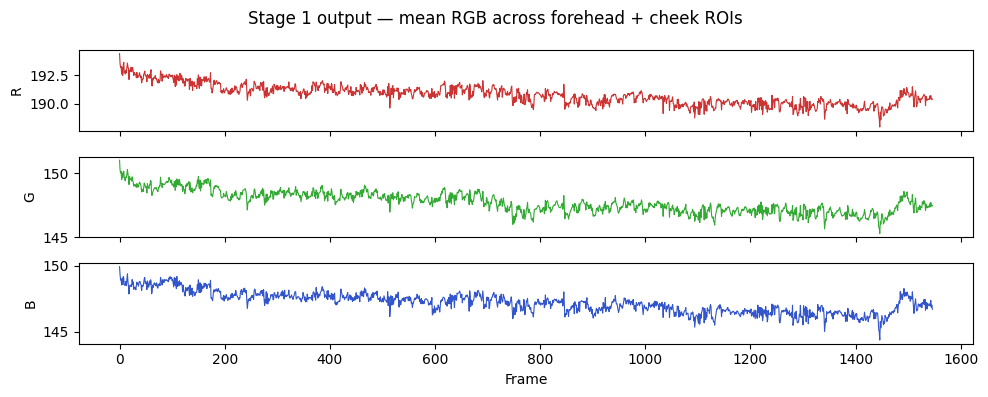

In [10]:
extractor = FaceROIExtractor()
try:
    rgb_series, fps = extractor.process_video(str(VIDEO_PATH))
finally:
    extractor.close()

print(f'Frames with detected face: {len(rgb_series)}')
print(f'Video fps: {fps:.1f}')
print(f'Duration: {len(rgb_series)/fps:.1f} seconds')
print(f'RGB time-series shape: {rgb_series.shape}  # (T, 3)')

fig, axes = plt.subplots(3, 1, figsize=(10, 4), sharex=True)
for ax, ch, color in zip(axes, [0, 1, 2], ['#cc3333', '#33aa33', '#3355cc']):
    ax.plot(rgb_series[:, ch], color=color, linewidth=0.8)
    ax.set_ylabel(['R', 'G', 'B'][ch])
axes[-1].set_xlabel('Frame')
fig.suptitle('Stage 1 output — mean RGB across forehead + cheek ROIs')
plt.tight_layout()
plt.show()

## Stage 2 — POS Algorithm, Bandpass Filter, and FFT (Task 2)

Project the RGB time-series onto a plane orthogonal to the skin-tone vector (POS algorithm, Wang et al. 2017). This suppresses motion and lighting noise that affects all three channels equally while preserving the pulse signal.

Then Butterworth bandpass filter (0.7–4.0 Hz ≈ 60–210 BPM) and FFT to find the dominant frequency — that is the heart rate.

Predicted heart rate (POS):   107.4 BPM


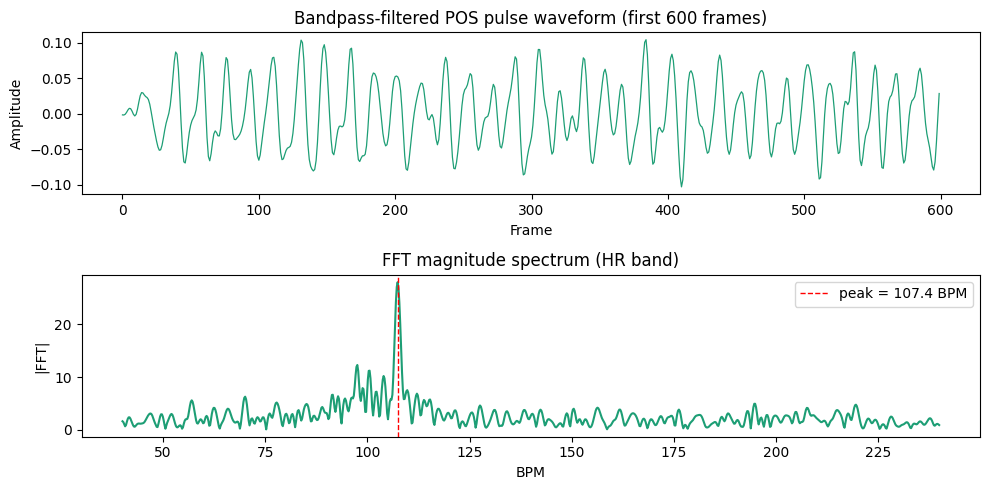

In [11]:
raw_pulse = pos_algorithm(rgb_series, fps)
filtered_pulse = butter_bandpass(raw_pulse, fps)
heart_rate_bpm, freqs, mags = estimate_heart_rate_fft(filtered_pulse, fps)

print(f'Predicted heart rate (POS):   {heart_rate_bpm:.1f} BPM')

fig, axes = plt.subplots(2, 1, figsize=(10, 5))
axes[0].plot(filtered_pulse[:600], linewidth=0.9, color='#1D9E75')
axes[0].set_title('Bandpass-filtered POS pulse waveform (first 600 frames)')
axes[0].set_xlabel('Frame')
axes[0].set_ylabel('Amplitude')

bpm_axis = freqs * 60
mask = (bpm_axis >= 40) & (bpm_axis <= 240)
axes[1].plot(bpm_axis[mask], mags[mask], color='#1D9E75')
axes[1].axvline(heart_rate_bpm, color='red', linestyle='--', linewidth=1,
                label=f'peak = {heart_rate_bpm:.1f} BPM')
axes[1].set_title('FFT magnitude spectrum (HR band)')
axes[1].set_xlabel('BPM')
axes[1].set_ylabel('|FFT|')
axes[1].legend()
plt.tight_layout()
plt.show()

## Stage 3 — HRV and Stress Index (Task 3)

Detect individual heartbeat peaks in the filtered pulse using `scipy.signal.find_peaks`. The time between consecutive peaks is the inter-beat interval (IBI).

- **SDNN** = standard deviation of normal-to-normal intervals — the HRV metric.
- **Stress index** = LF/HF power ratio normalized via sigmoid to `[0, 1]`. LF (0.04–0.15 Hz) ≈ sympathetic; HF (0.15–0.40 Hz) ≈ parasympathetic; high LF/HF ⇒ stress.

Beats detected: 97
HRV (SDNN):     109.6 ms
Stress index:   0.24  (0 = relaxed, 1 = stressed)


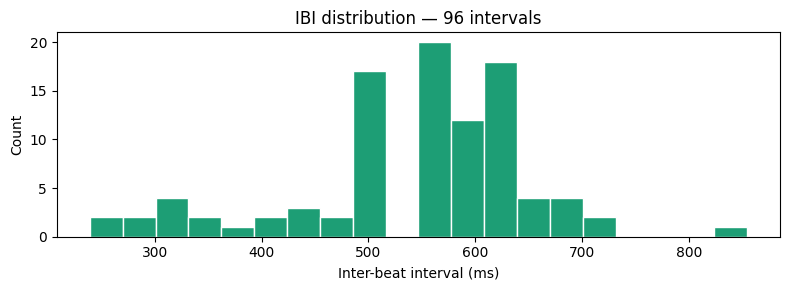

In [12]:
peaks = detect_pulse_peaks(filtered_pulse, fps)
ibi_ms = compute_ibi(peaks, fps)
sdnn_ms, stress_index, n_peaks = compute_hrv_metrics(filtered_pulse, fps)

print(f'Beats detected: {n_peaks}')
print(f'HRV (SDNN):     {sdnn_ms:.1f} ms')
print(f'Stress index:   {stress_index:.2f}  (0 = relaxed, 1 = stressed)')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ibi_ms, bins=20, color='#1D9E75', edgecolor='white')
ax.set_xlabel('Inter-beat interval (ms)')
ax.set_ylabel('Count')
ax.set_title(f'IBI distribution — {len(ibi_ms)} intervals')
plt.tight_layout()
plt.show()

## Final biomarker JSON — Shared API Contract

This is exactly what `POST /scan` returns to the frontend (and to Groups 3 & 4 in the integration project).

**Note on blood pressure:** classical rPPG cannot derive blood pressure without per-subject cuff calibration. Per the project plan, BP is currently a mocked field flagged in the writeup as a known limitation.

In [13]:
from backend.rppg.mock import generate_mock_biomarkers

bp = generate_mock_biomarkers()['biomarkers']['blood_pressure']

contract = {
    'biomarkers': {
        'heart_rate': int(round(heart_rate_bpm)),
        'hrv_sdnn': int(round(sdnn_ms)),
        'stress_index': float(stress_index),
        'blood_pressure': {
            'systolic': bp['systolic'],
            'diastolic': bp['diastolic'],
        },
    }
}

print(json.dumps(contract, indent=2))

{
  "biomarkers": {
    "heart_rate": 107,
    "hrv_sdnn": 110,
    "stress_index": 0.24,
    "blood_pressure": {
      "systolic": 142,
      "diastolic": 82
    }
  }
}


## Sanity check — Full pipeline via `run_pipeline()`

The cells above run each stage individually for pedagogy. The production code path used by `/scan` is a single function call. Verify it produces the same result.

In [14]:
result = run_pipeline(str(VIDEO_PATH))
print(json.dumps(result.to_contract_dict(), indent=2))

I0000 00:00:1778759335.265607 10804444 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M3 Max
W0000 00:00:1778759335.266434 10805879 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778759335.267954 10805878 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


{
  "biomarkers": {
    "heart_rate": 107,
    "hrv_sdnn": 110,
    "stress_index": 0.24,
    "blood_pressure": {
      "systolic": 139,
      "diastolic": 91
    }
  }
}


## Baseline comparison — POS vs CHROM (Deliverable 2)

The rubric asks for a comparison against at least one baseline algorithm. CHROM (de Haan & Jeanne, 2013) is the canonical pre-POS classical rPPG extractor. Both algorithms operate on the same RGB time-series extracted in Stage 1 — only the projection differs.

POS:   107.4 BPM
CHROM: 107.4 BPM


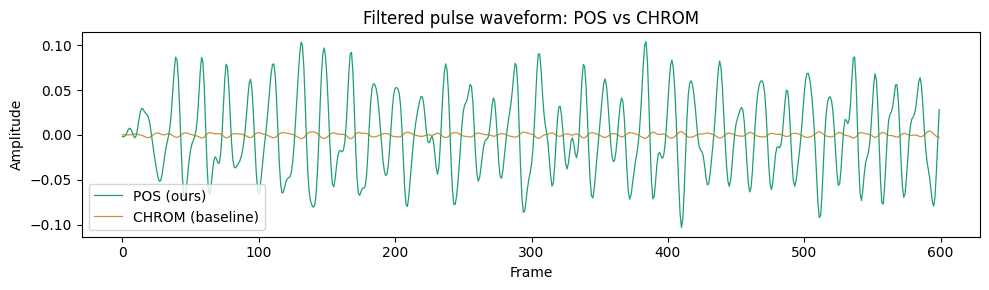

In [ ]:
chrom_hr, chrom_pulse = extract_heart_rate_chrom(rgb_series, fps)
print(f'POS:   {heart_rate_bpm:.1f} BPM')
print(f'CHROM: {chrom_hr:.1f} BPM')

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(filtered_pulse[:600], label='POS (ours)', color='#1D9E75', linewidth=0.9)
ax.plot(chrom_pulse[:600], label='CHROM (baseline)', color='#BA7517', linewidth=0.9, alpha=0.8)
ax.set_title('Filtered pulse waveform: POS vs CHROM')
ax.set_xlabel('Frame')
ax.set_ylabel('Amplitude')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated the full Group 1 rPPG pipeline on a 30-second facial video, producing a JSON object that matches the shared API contract consumed by Groups 3 and 4.

| Deliverable | Where to find it |
|---|---|
| 1. Working demo (this notebook) | `demo.ipynb` |
| 2. Accuracy report (MAE / RMSE / CHROM baseline) | `docs/evaluation_results.md` |
| 3. Technical writeup | `docs/technical_writeup.md` |
| 4. REST API endpoint | `backend/main.py` · live at https://vitalscan.bkre8tive.com |
| 5. (Stretch) Deep learning comparison | future work |